## Bölüm 1: Teorik Türetme (Analitik MLE)

Akıllı Şehir Planlaması için Trafik Modelleme ve Maksimum Olabilirlik Tahmini (MLE)

Şehirdeki ana caddeden bir dakikada geçen araç sayısını $k$ olarak varsayalım.  
$k$ değerinin Poisson dağılımına uyduğunu kabul ediyoruz: $k \sim \text{Poisson}(\lambda)$.

Olasılık kütle fonksiyonu (PMF) şöyle verilir:

$$
P(k \mid \lambda) = \frac{e^{-\lambda} \lambda^k}{k!}
$$

$n$ adet gözlemin bulunduğu bir veri seti $k_1, k_2, \dots, k_n$ için, **olabilirlik (likelihood) fonksiyonu**:

$$
L(\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda} \lambda^{k_i}}{k_i!}
$$

Optimizasyonu kolaylaştırmak için bu fonksiyonun **doğal logaritmasını** alıyoruz:

$$
\ell(\lambda) = \log L(\lambda) = \sum_{i=1}^{n} \Big(-\lambda + k_i \log(\lambda) - \log(k_i!) \Big)
$$

$\log(k_i!)$ terimi $\lambda$’ya bağlı olmadığından, optimizasyon sırasında ihmal edilebilir.  

Böylece sadeleştirilmiş log-olabilirlik fonksiyonu:

$$
\ell(\lambda) = \sum_{i=1}^{n} \Big(-\lambda + k_i \log(\lambda) \Big)
$$

$\lambda$ için **MLE tahmini** bulmak amacıyla log-olabilirlik fonksiyonunun türevini alıp sıfıra eşitliyoruz:

$$
\frac{d\ell(\lambda)}{d\lambda} = \sum_{i=1}^{n} \left(-1 + \frac{k_i}{\lambda} \right) = 0
$$

$\lambda$’yı çözmek:

$$
\hat{\lambda} = \frac{1}{n} \sum_{i=1}^{n} k_i
$$

Böylece, $\lambda$ için **MLE tahmini**, gözlenen verilerin **aritmetik ortalaması**dır.

## Bölüm 2: Python ile Sayısal (Numerical) MLE

# Trafik Akışı Modellemesi - Maksimum Olabilirlik Tahmini (MLE)

Bu notebook, Poisson dağılımı kullanarak trafik akışı verilerini analiz etmektedir.  
Amaç, dakikada geçen ortalama araç sayısını temsil eden $\lambda$ (lambda) parametresini tahmin etmektir.

$\lambda$ değerini Maksimum Olabilirlik Tahmini (MLE) ve sayısal optimizasyon yöntemleri ile bulacağız.

## Gerekli Kütüphanelerin İçe Aktarılması

Sayısal hesaplama, optimizasyon ve görselleştirme işlemleri için gerekli Python kütüphanelerini içe aktarıyoruz.

In [1]:
import numpy as np
import scipy.optimize as opt
from scipy.stats import poisson
import matplotlib.pyplot as plt

## Gözlemlenen Trafik Verisi

Veri seti, bir yol üzerinde bir dakikalık zaman aralıklarında geçen araç sayısını içermektedir.  
Gözlenen araç sayısının Poisson dağılımına uyduğunu varsayıyoruz.

In [2]:
# Gözlemlenen trafik verisi (1 dakikada geçen araç sayısı)
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9,
                         12, 11, 14, 10, 15])

print("Trafik verisi:", traffic_data)
print("Ortalama:", np.mean(traffic_data))

Trafik verisi: [12 15 10  8 14 11 13 16  9 12 11 14 10 15]
Ortalama: 12.142857142857142


In [3]:
def negative_log_likelihood(lam, data):
    """
    Poisson dağılımı için Negatif Log-Olabilirlik (NLL) hesaplar.

    log(k!) terimi λ'ya bağlı olmadığı için optimizasyon sırasında
    ihmal edilebilir.
    """

    n = len(data)

    # Log-likelihood hesaplama
    log_likelihood = np.sum(data * np.log(lam) - lam)

    # Negatif log-likelihood
    nll = -log_likelihood

    return nll

In [ ]:
# Başlangıç tahmini
initial_guess = 1.0

# Optimizasyon: NLL'yi minimize etmek Likelihood'u maximize etmek anlamına gelir
result = opt.minimize(
    negative_log_likelihood,
    initial_guess,
    args=(traffic_data,),
    bounds=[(0.001, None)]
)

lambda_mle = result.x[0]  # sayısal MLE

print(f"Sayısal Tahmin (MLE lambda): {lambda_mle}")
print(f"Analitik Tahmin (Ortalama): {np.mean(traffic_data)}")

Sayısal Tahmin (MLE lambda): 12.142846011159076
Analitik Tahmin (Ortalama): 12.142857142857142


### Sonuç

Sayısal optimizasyon ile elde edilen $\lambda$ değeri, veri setinin ortalamasına 
çok yakın çıkmıştır. Bu sonuç, Poisson dağılımı için maksimum olabilirlik 
tahmininin veri ortalamasına eşit olduğunu doğrulamaktadır.

## Bölüm 3: Model Karşılaştırma ve Görselleştirme

Bu bölümde, Bölüm 2’de bulduğumuz sayısal MLE ($\lambda$) değerini kullanarak 
Poisson olasılık kütle fonksiyonunu (PMF) çizeceğiz ve gözlemlenen veri histogramı ile karşılaştıracağız. 
Amacımız modelin verilere ne kadar iyi uyduğunu görselle gözlemlemektir.

In [6]:
# PMF values for possible car counts
x = np.arange(0, max(traffic_data)+5)  # slightly more than max for visualization
pmf_values = poisson.pmf(x, lambda_mle)

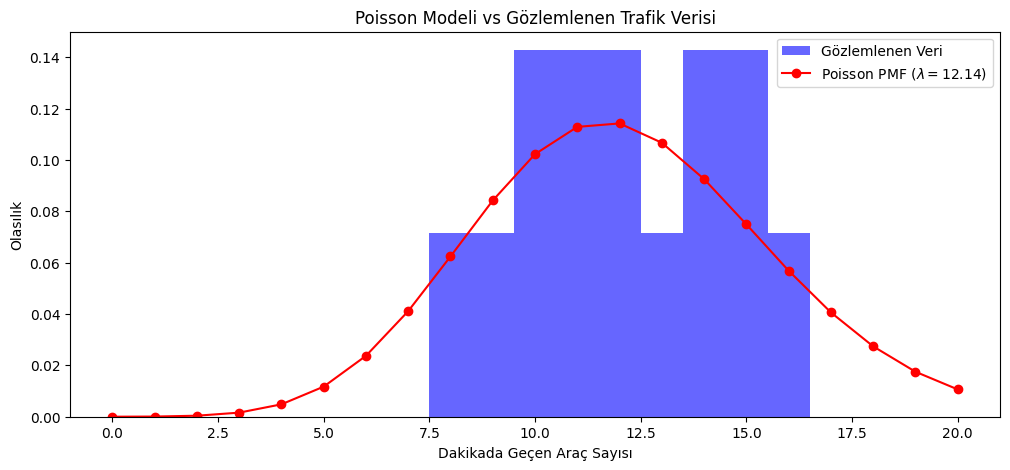

In [ ]:
plt.figure(figsize=(12,5))
# Histogram of observed traffic
plt.hist(traffic_data, 
         bins=np.arange(min(traffic_data)-0.5, max(traffic_data)+1.5), 
         density=True, 
         alpha=0.6, 
         color='blue', 
         label='Gözlemlenen Veri')

# PMF line
plt.plot(x, 
         pmf_values, 
         'o-', 
         color='red', 
         label=fr'Poisson PMF ($\lambda={lambda_mle:.2f}$)')

plt.xlabel('Dakikada Geçen Araç Sayısı')
plt.ylabel('Olasılık')
plt.title('Poisson Modeli vs Gözlemlenen Trafik Verisi')
plt.legend()
plt.show()

**Yorum:**

Grafikte kırmızı çizgi Poisson modelinin olasılık kütle fonksiyonunu göstermektedir, 
mavi çubuklar ise gözlemlenen veri histogramını temsil etmektedir. 
Modelin histogram ile örtüşmesi, Poisson dağılımının gözlemlenen trafik verisini iyi 
tahmin ettiğini göstermektedir.

## Bölüm 4: Gerçek Hayat Senaryosu – Outlier Analizi


Bu bölümde veri setimize yanlışlıkla kaydedilen “200” araçlık bir hatalı gözlem (outlier) ekleyeceğiz. 
Amacımız, bu uç değerin MLE tahmini (ve dolayısıyla ortalama) üzerindeki etkisini görmek 
ve belediyenin trafik planlamasında nasıl bir hataya yol açabileceğini tartışmaktır.

In [10]:
# Mevcut trafik verisi
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9,
                         12, 11, 14, 10, 15])

# Outlier ekleme
traffic_data_with_outlier = np.append(traffic_data, 200)

# Negatif Log-Likelihood fonksiyonu
def negative_log_likelihood(lam, data):
    """
    Poisson dağılımı için Negatif Log-Likelihood hesaplar.
    log(k!) terimi optimizasyon sırasında sabit olduğu için ihmal edilebilir.
    """
    n = len(data)
    nll = -np.sum(data * np.log(lam) - lam)  # log(k!) ihmal edildi
    return nll

In [11]:
# Başlangıç tahmini
initial_guess = 1.0

# Optimizasyon: NLL'yi minimize ederek MLE bulma
result = opt.minimize(negative_log_likelihood, 
                      initial_guess, 
                      args=(traffic_data_with_outlier,), 
                      bounds=[(0.001, None)])

lambda_mle_outlier = result.x[0]

print(f"Sayısal Tahmin (MLE lambda) – Outlier ile: {lambda_mle_outlier:.2f}")
print(f"Analitik Tahmin (Ortalama) – Outlier ile: {np.mean(traffic_data_with_outlier):.2f}")

Sayısal Tahmin (MLE lambda) – Outlier ile: 24.67
Analitik Tahmin (Ortalama) – Outlier ile: 24.67


**Yorum:**

- Outlier (200 araç) MLE tahminini ve ortalamayı ciddi şekilde yükseltmektedir.
- Bu durum, belediyenin trafik planlamasında (ör. yol genişletme kararı) yanlış tahminlere yol açabilir.
- MLE, özellikle Poisson modeli gibi ortalamaya dayalı modellerde uç değerlere karşı hassastır.
- Gerçek hayat verilerinde outlier tespiti ve temizleme adımları kritik öneme sahiptir.